In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

100%|████████████████████████████████████████████████████████████████████████████████| 170M/170M [04:01<00:00, 705kB/s]
C:\Users\Anvayi\AppData\Roaming\Python\Python312\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


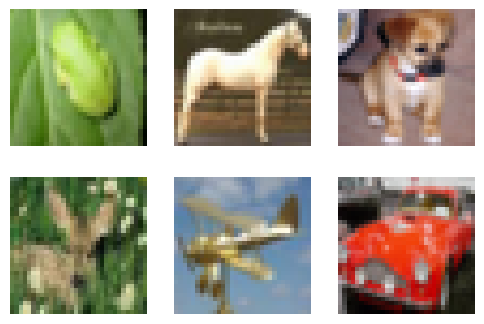

In [3]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

plt.figure(figsize=(6,4))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.axis('off')

plt.show()

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 16, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3)
        
        self.fc1 = nn.Linear(32 * 6 * 6, 64)
        self.fc2 = nn.Linear(64, 10)
    
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        
        x = x.view(-1, 32 * 6 * 6)
        
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

model = CNN()

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
loss_list = []

for epoch in range(1):  
    running_loss = 0.0
    
    for i, (images, labels) in enumerate(trainloader):
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Print every 50 batches (so you see progress)
        if i % 50 == 0:
            print(f"Epoch {epoch+1}, Batch {i}, Loss: {loss.item()}")
    
    avg_loss = running_loss / len(trainloader)
    loss_list.append(avg_loss)
    
    print(f"\nEpoch {epoch+1} Completed, Avg Loss: {avg_loss}\n")

Epoch 1, Batch 0, Loss: 1.2142771482467651
Epoch 1, Batch 50, Loss: 1.211961269378662
Epoch 1, Batch 100, Loss: 1.131039023399353
Epoch 1, Batch 150, Loss: 1.1855323314666748
Epoch 1, Batch 200, Loss: 1.0901347398757935
Epoch 1, Batch 250, Loss: 1.2933402061462402
Epoch 1, Batch 300, Loss: 0.9910038113594055
Epoch 1, Batch 350, Loss: 1.1250636577606201
Epoch 1, Batch 400, Loss: 0.9608529210090637
Epoch 1, Batch 450, Loss: 1.0368603467941284
Epoch 1, Batch 500, Loss: 1.8818057775497437
Epoch 1, Batch 550, Loss: 0.9599084854125977
Epoch 1, Batch 600, Loss: 1.4243398904800415
Epoch 1, Batch 650, Loss: 1.1952019929885864
Epoch 1, Batch 700, Loss: 1.3871701955795288
Epoch 1, Batch 750, Loss: 1.1296343803405762
Epoch 1, Batch 800, Loss: 0.9270933866500854
Epoch 1, Batch 850, Loss: 1.0978411436080933
Epoch 1, Batch 900, Loss: 1.0802944898605347
Epoch 1, Batch 950, Loss: 1.2852624654769897
Epoch 1, Batch 1000, Loss: 1.4481481313705444
Epoch 1, Batch 1050, Loss: 1.1933268308639526
Epoch 1, Batc

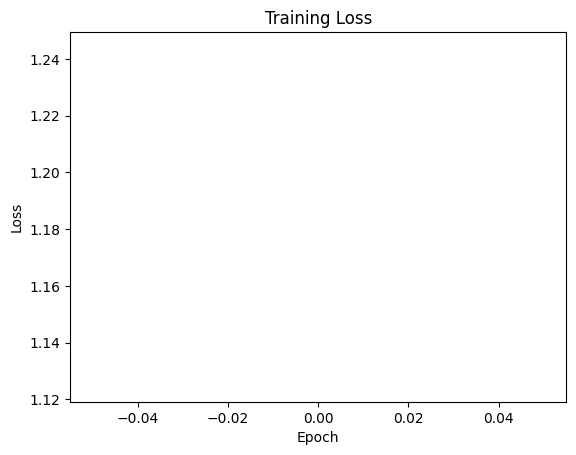

In [8]:
plt.figure()
plt.plot(loss_list)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [9]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total

print("Test Accuracy:", accuracy)

Test Accuracy: 0.5872


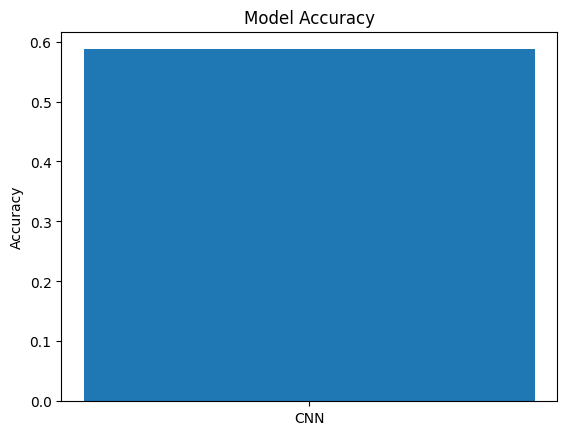

In [10]:
plt.figure()
plt.bar(["CNN"], [accuracy])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.show()